# Optimizing Rank-Order Doctor-to-Hospital Assignments: Greedy vs. Linear Sum Assignment

#### **Authors:** Arnav Mankad, Bobby Wang, Moria Li

## Overview

The goal of this project is to assign $N$ doctors to $K$ hospitals based on each doctor's ranked preferences while respecting hospital capacity constraints. Each doctor ranks the hospitals from most to least preferred, where a lower rank represents a more preferred hospital.

Let

* $r_{nk}$ = rank assigned by doctor $n$ to hospital $k$
* $c_k$ = maximum capacity of hospital $k$
* $x_{nk} = 1$ if doctor $n$ is assigned to hospital $k$, and $0$ otherwise

The objective is to minimize the total preference rank across all doctors:

$$
\min \sum_{n=1}^{N}\sum_{k=1}^{K} r_{nk}x_{nk}
$$

subject to each doctor being assigned to exactly one hospital:

$$
\sum_{k=1}^{K} x_{nk} = 1
\qquad \forall n
$$

and each hospital remaining within its capacity:

$$
\sum_{n=1}^{N} x_{nk} \leq c_k
\qquad \forall k
$$

with

$$
x_{nk} \in \{0,1\}.
$$



### Approaches

We will compare two approaches to solving the assignment problem.

**Greedy Baseline [1]:** Doctors are processed sequentially. Each doctor is assigned to their highest-ranked hospital that still has available capacity. Once an assignment is made, it is not reconsidered. This provides a simple baseline but does not necessarily minimize the total preference rank across all doctors because each assignment is made based only on the current doctor's preference without considering its effect on later assignments.

**Linear Sum Assignment:** We originally intended to use the Hungarian method [2], a classical algorithm for solving the linear assignment problem. For the actual implementation, we will use SciPy's `scipy.optimize.linear_sum_assignment` function, which solves the problem using a modified Jonker–Volgenant algorithm with no initialization [3]. While both algorithms solve the same optimization problem, the Jonker–Volgenant algorithm uses a different and generally more efficient procedure for finding the optimal assignment. Doctor preference ranks are used as assignment costs, so minimizing the total cost corresponds to minimizing the total preference rank. Because hospitals may accept multiple doctors, each hospital is represented by multiple assignment slots according to its capacity. This converts the capacity-constrained problem into a linear sum assignment problem that can be solved using `linear_sum_assignment`. This optimization-based approach provides a globally optimal solution for the defined objective and can be directly compared with the simpler greedy baseline.



### Evaluation

The greedy and linear sum assignment approaches will be run on the same sets of doctor preferences and hospital capacities. Their resulting assignments will be compared using three metrics:

1. **Total Preference Rank**

$$
R_{\text{total}} = \sum_{n=1}^{N} r_{n,a(n)}
$$

where $a(n)$ is the hospital assigned to doctor $n$. A lower total rank indicates a better overall assignment.

2. **Average Assigned Rank**

$$
R_{\text{avg}} = \frac{R_{\text{total}}}{N}
$$

This measures the average preference rank received by a doctor.

3. **Percentage Receiving First Choice**

$$
P_{\text{first}} =
\frac{\text{Number of doctors assigned to their first choice}}{N}
\times 100
$$

A higher percentage indicates that more doctors received their most-preferred hospital.

We will generate test cases with different numbers of doctors, hospital capacities, and randomly generated preference rankings. Both approaches will receive the same input for each test so that their performance can be directly compared.



### Assumptions and Constraints

The assignment problem uses the following assumptions:

* Each doctor provides a complete ranking of all $K$ hospitals.
* Rank $1$ represents a doctor's most-preferred hospital.
* Each doctor must be assigned to exactly one hospital.
* Each hospital has a fixed maximum capacity $c_k$.
* Total hospital capacity is sufficient to assign every doctor:

$$
\sum_{k=1}^{K} c_k \geq N
$$

* Hospitals do not have preferences over doctors.
* Hospitals do not need to be filled to their maximum capacity.
* Rankings represent preference order but not the strength of preference between hospitals.

## Implementations
### The Greedy Approach

In [2]:
def greedy_assignment(preferences, capacities):
    """
    Assign doctors to hospitals using a greedy approach.

    Doctors are processed sequentially. Each doctor is assigned to their
    highest-ranked hospital that still has available capacity.

    Parameters
    ----------
    preferences : list[list[int]]
        Each doctor's hospital preferences, ordered from most to least preferred.

    capacities : list[int]
        Maximum number of doctors each hospital can accept.

    Returns
    -------
    assignments : list[int]
        Hospital assigned to each doctor.
    total_rank : int
        Sum of all assigned preference ranks.
    average_rank : float
        Average preference rank received.
    first_choice_percentage : float
        Percentage of doctors who receive their first choice.
    """

    n_doctors = len(preferences)

    # Track available capacity without modifying the original list
    remaining_capacity = capacities.copy()

    # -1 indicates that a doctor has not yet been assigned
    assignments = [-1] * n_doctors
    assigned_ranks = []

    # Process doctors sequentially
    for doctor in range(n_doctors):

        # Check hospitals from most to least preferred
        for rank, hospital in enumerate(preferences[doctor], start=1):

            if remaining_capacity[hospital] > 0:
                assignments[doctor] = hospital
                remaining_capacity[hospital] -= 1
                assigned_ranks.append(rank)
                break

        # This should not occur if total capacity is sufficient
        if assignments[doctor] == -1:
            raise ValueError(
                f"Doctor {doctor} could not be assigned. "
                "Check hospital capacities."
            )

    # Calculate performance metrics
    total_rank = sum(assigned_ranks)
    average_rank = total_rank / n_doctors

    first_choices = sum(rank == 1 for rank in assigned_ranks)
    first_choice_percentage = 100 * first_choices / n_doctors

    return (
        assignments,
        total_rank,
        average_rank,
        first_choice_percentage
    )

### Scipy Approach - Linear Sum Assignment


In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment

In [ ]:
def scipy_linear_sum_assignment(ranking, capacity):
    """
    Assign doctors to hospitals using SciPy's linear sum assignment approach.

    Hospital preference ranks are used as assignment costs. Hospitals with
    multiple available positions are represented by repeated assignment slots
    according to their capacity.

    Parameters
    ----------
    ranking : np.ndarray
        An n x k matrix where n is the number of doctors and k is the number
        of hospitals. Each element ranking[i, j] represents doctor i's rank
        for hospital j, where a lower value indicates a higher preference.

    capacity : list[int]
        Maximum number of doctors each hospital can accept.

    Returns
    -------
    row_ind : np.ndarray
        Indices of the doctors included in the optimal assignment.
    col_ind : np.ndarray
        Indices of the hospital capacity slots assigned to each doctor.
    """

    n, k = ranking.shape

    # Create a cost matrix with one column for every available hospital position
    m = sum(capacity)
    cost = np.zeros((n, m))

    for i in range(n):

        # Repeat each hospital's rank according to its available capacity
        cost_i = np.concatenate([
            ranking[i, j] * np.ones(capacity[j])
            for j in range(k)
        ])

        cost[i, :] = cost_i

    return linear_sum_assignment(cost)

[1 0 2]


### Test Data & Comparison

We generate reproducible test cases with different numbers of doctors,
hospitals, and hospital capacities. Each doctor receives a complete random
ranking of all hospitals, and hospital capacities are generated such that
the total capacity is sufficient to assign every doctor.

The Greedy and Linear Sum Assignment approaches are evaluated on exactly
the same test data using total preference rank, average assigned rank, and
the percentage of doctors receiving their first choice.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

# ------------------------------------------------------------
# Generate random test data
# ------------------------------------------------------------
def generate_test_data(n, k, seed=None, extra_capacity=0):
    """
    Generate doctor preferences and hospital capacities for testing.

    Parameters
    ----------
    n : int
        Number of doctors.

    k : int
        Number of hospitals.

    seed : int, optional
        Random seed used to make the generated preferences reproducible.

    extra_capacity : int, optional
        Number of hospital slots in excess of the number of doctors.
        The default is 0.

    Returns
    -------
    preferences : list[list[int]]
        Each doctor's hospital preferences, ordered from most to least preferred.

    capacities : list[int]
        Maximum number of doctors each hospital can accept.
    """

    rng = np.random.default_rng(seed)

    # Generate a complete random ranking of all hospitals for each doctor
    preferences = [
        rng.permutation(k).tolist()
        for _ in range(n)
    ]

    # Distribute enough capacity to accommodate all doctors
    capacities = [n // k] * k

    for hospital in rng.choice(
        k,
        size=n % k,
        replace=False
    ):
        capacities[hospital] += 1

    # Add any additional capacity requested for the test case
    for hospital in rng.integers(0, k, size=extra_capacity):
        capacities[hospital] += 1

    return preferences, capacities

In [8]:
# ------------------------------------------------------------
# Convert ordered preferences to a rank matrix
# ------------------------------------------------------------
def to_rank_matrix(preferences):
    """
    Convert ordered doctor preferences into a hospital rank matrix.

    Parameters
    ----------
    preferences : list[list[int]]
        Each doctor's hospital preferences, ordered from most to least preferred.

    Returns
    -------
    ranking : np.ndarray
        Matrix where ranking[i, j] is doctor i's preference rank
        for hospital j. Lower values indicate higher preference.

    Example
    -------
    [2, 0, 1] becomes [2, 3, 1], meaning:

    Hospital 0 has rank 2
    Hospital 1 has rank 3
    Hospital 2 has rank 1
    """

    n = len(preferences)
    k = len(preferences[0])

    ranking = np.zeros((n, k), dtype=int)

    for doctor in range(n):
        for rank, hospital in enumerate(
            preferences[doctor],
            start=1
        ):
            ranking[doctor, hospital] = rank

    return ranking

In [9]:
# ------------------------------------------------------------
# Convert Linear Sum Assignment slots back to hospitals
# ------------------------------------------------------------
def convert_linear_sum_output(
    row_ind,
    col_ind,
    capacities,
    n_doctors
):
    """
    Convert doctor-to-slot assignments returned by linear_sum_assignment
    into doctor-to-hospital assignments.

    Each hospital is represented by multiple slots according to its capacity.

    Parameters
    ----------
    row_ind : np.ndarray
        Doctor indices returned by linear_sum_assignment.

    col_ind : np.ndarray
        Assigned hospital-slot indices returned by linear_sum_assignment.

    capacities : list[int]
        Maximum number of doctors each hospital can accept.

    n_doctors : int
        Total number of doctors.

    Returns
    -------
    assignments : list[int]
        Hospital assigned to each doctor.
    """

    # Map each capacity slot back to its corresponding hospital
    slot_to_hospital = []

    for hospital, capacity in enumerate(capacities):
        slot_to_hospital.extend(
            [hospital] * capacity
        )

    assignments = [-1] * n_doctors

    # Convert each assigned slot into the corresponding hospital
    for doctor, slot in zip(row_ind, col_ind):
        assignments[doctor] = slot_to_hospital[slot]

    return assignments

In [10]:
# ------------------------------------------------------------
# Evaluate an assignment using the three defined metrics
# ------------------------------------------------------------
def evaluate(preferences, assignments):
    """
    Evaluate an assignment using the three project metrics.

    Parameters
    ----------
    preferences : list[list[int]]
        Each doctor's hospital preferences, ordered from most to least preferred.

    assignments : list[int]
        Hospital assigned to each doctor.

    Returns
    -------
    total_rank : int
        Sum of the preference ranks received by all doctors.

    average_rank : float
        Average preference rank received by a doctor.

    first_choice_percentage : float
        Percentage of doctors assigned to their first-choice hospital.
    """

    # Determine the preference rank of each doctor's assigned hospital
    ranks = [
        preferences[i].index(assignments[i]) + 1
        for i in range(len(assignments))
    ]

    # Calculate the three evaluation metrics
    total_rank = sum(ranks)
    average_rank = np.mean(ranks)
    first_choice_percentage = (
        np.mean(np.array(ranks) == 1) * 100
    )

    return (
        total_rank,
        average_rank,
        first_choice_percentage
    )

In [11]:
# ------------------------------------------------------------
# Compare Greedy and Linear Sum Assignment on the same test data
# ------------------------------------------------------------
def compare_methods(preferences, capacities):
    """
    Run both assignment approaches on the same input and compare
    their results using the three project evaluation metrics.
    """

    # Greedy approach
    greedy_result = greedy_assignment(
        preferences,
        capacities
    )

    greedy_assignments = greedy_result[0]


    # Linear Sum Assignment approach
    ranking = to_rank_matrix(preferences)

    row_ind, col_ind = scipy_linear_sum_assignment(
        ranking,
        capacities
    )

    linear_sum_assignments = convert_linear_sum_output(
        row_ind,
        col_ind,
        capacities,
        len(preferences)
    )


    # Evaluate both approaches using the same three metrics
    greedy_metrics = evaluate(
        preferences,
        greedy_assignments
    )

    linear_sum_metrics = evaluate(
        preferences,
        linear_sum_assignments
    )


    # Return results in a table for direct comparison
    return pd.DataFrame(
        [
            ["Greedy", *greedy_metrics],
            ["Linear Sum Assignment", *linear_sum_metrics]
        ],
        columns=[
            "Method",
            "Total Rank",
            "Average Rank",
            "First Choice (%)"
        ]
    )

#### Small Test

A small manually verifiable example is used to confirm that both approaches
respect hospital capacities and to demonstrate how the globally optimized
assignment can differ from the sequential greedy assignment.

In [12]:
# Small manually verifiable test case
# Three doctors rank three hospitals, with one available position per hospital.
# This example demonstrates a case where the greedy approach does not produce
# the minimum possible total preference rank.

preferences = [
    [0, 1, 2],
    [0, 1, 2],
    [1, 0, 2]
]

capacities = [1, 1, 1]

compare_methods(
    preferences,
    capacities
)

,Method,Total Rank,Average Rank,First Choice (%)
0,Greedy,6,2.000000,33.333333
1,Linear Sum Assignment,5,1.666667,66.666667


#### Random Test

A larger reproducible test is generated with 100 doctors and 5 hospitals.
Additional hospital capacity is included to test the assumption that total
hospital capacity may exceed the number of doctors.

In [13]:
# Random test with 100 doctors and 5 hospitals
# Ten additional slots are included so that total capacity exceeds
# the number of doctors, while still satisfying all capacity constraints.

preferences, capacities = generate_test_data(
    n=100,
    k=5,
    seed=42,
    extra_capacity=10
)

print("Hospital capacities:", capacities)
print("Total capacity:", sum(capacities))
print("Number of doctors:", len(preferences))

compare_methods(
    preferences,
    capacities
)

Hospital capacities: [20, 24, 22, 23, 21]
Total capacity: 110
Number of doctors: 100


,Method,Total Rank,Average Rank,First Choice (%)
0,Greedy,108,1.08,95.0
1,Linear Sum Assignment,105,1.05,95.0


#### Different Problem Sizes

To evaluate how the two approaches perform across different problem sizes, we test several combinations of numbers of doctors and hospitals. Each test uses newly generated preference rankings and hospital capacities, and both methods are evaluated on the same input data.

In [14]:
# Compare the two approaches across several problem sizes.
# Each test uses a different number of doctors and hospitals,
# with newly generated preference rankings and capacities.

results = []

test_cases = [
    (10, 3),
    (50, 5),
    (100, 5),
    (250, 10),
    (500, 10)
]

for n, k in test_cases:

    preferences, capacities = generate_test_data(
        n=n,
        k=k,
        seed=42 + n
    )

    result = compare_methods(
        preferences,
        capacities
    )

    result["Doctors"] = n
    result["Hospitals"] = k

    results.append(result)


results_df = pd.concat(
    results,
    ignore_index=True
)

results_df

,Method,Total Rank,Average Rank,First Choice (%),Doctors,Hospitals
0,Greedy,12,1.200,90.0,10,3
1,Linear Sum Assignment,11,1.100,90.0,10,3
2,Greedy,70,1.400,80.0,50,5
3,Linear Sum Assignment,57,1.140,86.0,50,5
4,Greedy,113,1.130,93.0,100,5
5,Linear Sum Assignment,107,1.070,93.0,100,5
6,Greedy,320,1.280,88.8,250,10
7,Linear Sum Assignment,272,1.088,91.2,250,10
8,Greedy,599,1.198,89.2,500,10
9,Linear Sum Assignment,543,1.086,91.4,500,10


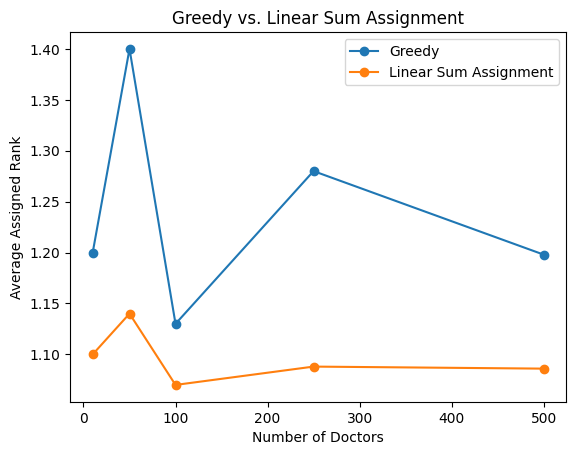

In [15]:
# Plot average assigned rank across different problem sizes.
# Lower average rank indicates that doctors are receiving
# hospitals that are higher in their preference rankings.

for method in ["Greedy", "Linear Sum Assignment"]:

    subset = results_df[
        results_df["Method"] == method
    ]

    plt.plot(
        subset["Doctors"],
        subset["Average Rank"],
        marker="o",
        label=method
    )


plt.xlabel("Number of Doctors")
plt.ylabel("Average Assigned Rank")
plt.title("Greedy vs. Linear Sum Assignment")
plt.legend()
plt.show()

## Conclusion

This project provides a framework for testing two approaches to the doctor-to-hospital assignment problem: a Greedy baseline and an optimization-based Linear Sum Assignment approach. Both methods are evaluated on the same preference rankings and hospital capacities using total preference rank, average assigned rank, and percentage receiving their first choice.

Across the generated test cases, the Linear Sum Assignment approach produced a lower total preference rank than the Greedy baseline, consistent with its goal of globally minimizing the defined objective. The testing framework also allows the two approaches to be compared across different problem sizes and capacity configurations.

## References
1. García, A. Greedy algorithms: a review and open problems. J Inequal Appl 2025, 11 (2025). https://doi.org/10.1186/s13660-025-03254-1
2. Kuhn, H.W. (1955), The Hungarian method for the assignment problem. Naval Research Logistics, 2: 83-97. https://doi.org/10.1002/nav.3800020109
3. DF Crouse. On implementing 2D rectangular assignment algorithms. IEEE Transactions on Aerospace and Electronic Systems, 52(4):1679-1696, August 2016, https://doi.org/10.1109/TAES.2016.140952

## Contributions
- Arnav Mankad - intro of the proposal, greedy approach implementation
- Bobby Wang - intro of the proposal, scipy method implementation
- Sophia Cho - description of the two methods in the proposal
- Monia Li - test data generation and data validation script